In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


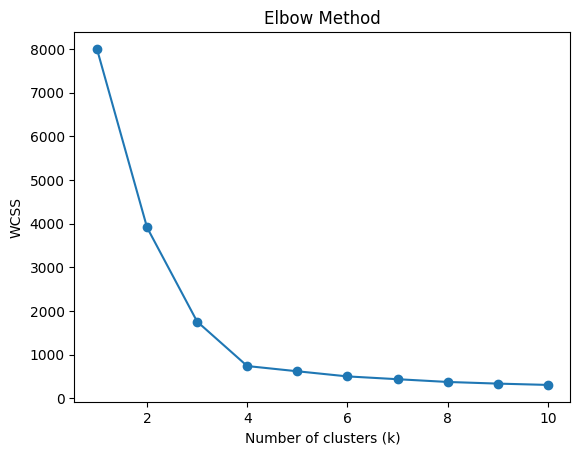

Silhouette Score: 0.7843727073779272


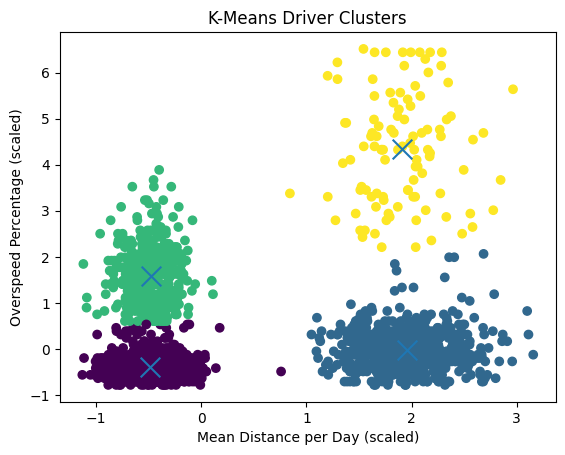

In [4]:
# K-Means clustering with Elbow (WCSS), Silhouette Score, and Cluster Visualization

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/ML/driver-data.csv")

# Use the same columns from the CSV
X = df[['mean_dist_day', 'mean_over_speed_perc']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# Elbow Method (WCSS)
# ---------------------------
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# ---------------------------
# Choose optimal k (from elbow, k = 3)
# ---------------------------
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# ---------------------------
# Silhouette Score
# ---------------------------
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

# ---------------------------
# Cluster Visualization
# ---------------------------
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            marker='x', s=200)
plt.xlabel("Mean Distance per Day (scaled)")
plt.ylabel("Overspeed Percentage (scaled)")
plt.title("K-Means Driver Clusters")
plt.show()